# Электроэнергия РФ: обновлённый leakage-safe эксперимент с KAN

Этот ноутбук является обновлённой версией эксперимента по данным электроэнергии РФ.

Что изменено по сравнению с ранним вариантом:
- постановка исправлена на leakage-safe прогнозирование цены на `t+1`;
- суточные потери используются только с лагом `1` день;
- месячные тарифные признаки используются только с лагом `1` месяц;
- добавлены настоящие `KAN` и `HybridKAN` на `PyTorch`;
- сохранены артефакты интерпретации: `phi`-функции, важность признаков и важность каналов.


## Что есть в ноутбуке

1. Подключение готового пайплайна из `russian_electricity_real_kan.py`
2. Повторный запуск полного эксперимента при необходимости
3. Загрузка итоговых метрик и summary
4. Просмотр leakage-safe датасета
5. Просмотр графиков качества и интерпретации модели


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
OUT_DIR = ROOT / 'analysis_outputs'

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


In [2]:
import russian_electricity_real_kan as rek

print('Модуль подключён:', rek.__file__)
print('Папка с результатами:', OUT_DIR)


Модуль подключён: /Users/kirill/Desktop/ВКР ИТМО/russian_electricity_real_kan.py
Папка с результатами: /Users/kirill/Desktop/ВКР ИТМО/analysis_outputs


## Повторный запуск полного эксперимента

Если нужно пересчитать все результаты, снимите комментарий и выполните следующую ячейку.
Она пересоберёт leakage-safe датасет, заново обучит модели и обновит все файлы в `analysis_outputs`.


In [3]:
# rek.main()

## Краткая сводка


In [4]:
summary_json = OUT_DIR / 'russian_electricity_real_kan_summary.json'
summary_md = OUT_DIR / 'russian_electricity_real_kan_summary.md'

summary = json.loads(summary_json.read_text(encoding='utf-8'))
summary


{'regions_total': 34,
 'regions_in_panel': 34,
 'common_window_start': '2023-08-30',
 'common_window_end': '2023-12-31',
 'panel_rows': 99278,
 'panel_columns': 66,
 'datetime_min': '2023-08-30 00:00:00',
 'datetime_max': '2023-12-31 22:00:00',
 'train_rows': 50616,
 'val_rows': 24000,
 'test_rows': 24662,
 'target_mean': 1605.8152516990672,
 'target_std': 445.2317821844825,
 'best_model_overall': 'HistGradientBoosting',
 'best_rmse_overall': 101.3182203919961,
 'best_kan_model': 'KAN',
 'best_kan_rmse': 149.51226806640625}

In [5]:
display(Markdown(summary_md.read_text(encoding='utf-8')))


## Обновлённый эксперимент по электроэнергии РФ

- Постановка исправлена на leakage-safe прогнозирование цены на 1 час вперёд (`t+1`).
- Суточные потери используются только с лагом 1 день, месячные тарифные показатели — только с лагом 1 месяц.
- Итоговая панель: 99278 наблюдений, 34 региона, период 2023-08-30 00:00:00 — 2023-12-31 22:00:00.

## Метрики моделей

               model       RMSE        MAE       R2           note
HistGradientBoosting 101.318220  55.347103 0.943889           full
               Ridge 113.186760  67.621788 0.929973           full
    LinearRegression 113.289505  67.735489 0.929846           full
   NaiveCurrentPrice 147.702842  85.486850 0.880753   forecast_t+1
                 KAN 149.512268  97.166214 0.877813 torch_true_kan
           HybridKAN 181.231644 142.163132 0.820469 torch_true_kan
    SeasonalNaiveDay 245.302756 161.840938 0.671091   forecast_t+1
   SeasonalNaiveWeek 290.429422 200.868537 0.538945   forecast_t+1

## Наиболее важные каналы для HybridKAN

         group  baseline_rmse  rmse_after_permutation  rmse_delta
 price_history     181.231644              518.464355  337.232712
      calendar     181.231644              248.994415   67.762772
  load_history     181.231644              209.344467   28.112823
generation_mix     181.231644              194.611008   13.379364
monthly_lagged     181.231644              188.945587    7.713943

## Наиболее важные признаки первого KAN-слоя

               feature  importance
purchase_price_rub_mwh    1.534535
    sale_price_rub_mwh    1.232530
              sin_hour    1.107933
              cos_hour    1.062228
                   Час    0.894093
           ВЭС.3_first    0.862220
                  hour    0.838029
           АЭС.1_first    0.837661
           price_lag_2    0.799499
           price_lag_3    0.790747

## Короткая интерпретация

- Лучшая модель overall: `HistGradientBoosting` с RMSE `101.318`.
- Лучшая модель семейства KAN: `KAN` с RMSE `149.512`.
- Наиболее сложный регион по средней абсолютной ошибке: `Республика Дагестан` (`186.11`).
- `phi`-функции сохранены отдельно для визуального анализа нелинейностей первого KAN-слоя.

## Итоговые метрики моделей


In [6]:
metrics = pd.read_csv(OUT_DIR / 'russian_electricity_real_kan_metrics.csv')
metrics


,model,RMSE,MAE,R2,note
0,HistGradientBoosting,101.318220,55.347103,0.943889,full
1,Ridge,113.186760,67.621788,0.929973,full
2,LinearRegression,113.289505,67.735489,0.929846,full
3,NaiveCurrentPrice,147.702842,85.486850,0.880753,forecast_t+1
4,KAN,149.512268,97.166214,0.877813,torch_true_kan
5,HybridKAN,181.231644,142.163132,0.820469,torch_true_kan
6,SeasonalNaiveDay,245.302756,161.840938,0.671091,forecast_t+1
7,SeasonalNaiveWeek,290.429422,200.868537,0.538945,forecast_t+1


In [7]:
plt.figure(figsize=(10, 4))
plt.bar(metrics['model'], metrics['RMSE'], color=['#2a9d8f' if m == metrics.iloc[0]['model'] else '#a8dadc' for m in metrics['model']])
plt.xticks(rotation=25)
plt.ylabel('RMSE')
plt.title('Сравнение моделей по RMSE')
plt.tight_layout()
plt.show()


/var/folders/zd/7ns72txx3jsgg93n1jydwd880000gn/T/ipykernel_27770/499796173.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Leakage-safe датасет


In [8]:
panel = pd.read_csv(OUT_DIR / 'russian_electricity_panel_dataset_leakage_safe.csv', parse_dates=['Дата', 'datetime', 'month'])
print(panel.shape)
panel.head()


(99278, 66)


,Субъект РФ,Дата,Час,ГЭС_first,АЭС_first,ТЭС_first,СЭС_first,ВЭС_first,ГЭС.1_first,АЭС.1_first,ТЭС.1_first,СЭС.1_first,ВЭС.1_first,ГЭС.2_first,АЭС.2_first,ТЭС.2_first,СЭС.2_first,ВЭС.2_first,ГЭС.3_first,АЭС.3_first,ТЭС.3_first,СЭС.3_first,ВЭС.3_first,planned_consumption_mwh,planned_export_mwh,planned_import_mwh,purchase_price_rub_mwh,sale_price_rub_mwh,full_planned_consumption_mwh,recipient_count,total_outflow,mean_outflow,max_outflow,month,daily_losses_prev_day_mwh,prev_month_so_service_cost,prev_month_cfr_service_cost,prev_month_peak_demand_mw,prev_month_energy_power_cost,prev_month_grid_losses_volume,prev_month_grid_loss_tariff_rate,region,datetime,price_lag_1,cons_lag_1,price_lag_2,cons_lag_2,price_lag_3,cons_lag_3,price_lag_24,cons_lag_24,price_lag_25,cons_lag_25,price_lag_48,cons_lag_48,price_lag_168,cons_lag_168,target_price_t_plus_1,hour,dayofweek,month_num,is_weekend,sin_hour,cos_hour,sin_dow,cos_dow
0,Новгородская область,2023-08-30,0,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,413.967,176.550,536.120,1387.01,1380.61,424.467,3,176.549928,58.849976,100.453327,2023-08-01,128.948,NaN,NaN,NaN,NaN,NaN,NaN,Новгородская область,2023-08-30 00:00:00,1368.87,431.630,1557.51,453.558,1880.80,467.058,1200.69,406.800,1192.05,427.242,1198.99,412.540,1138.96,395.727,1259.25,0,2,8,0,0.000000,1.000000,0.974928,-0.222521
1,Новгородская область,2023-08-30,1,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,406.305,208.509,561.352,1259.25,1253.07,416.805,3,208.509088,69.503029,106.198989,2023-08-01,128.948,NaN,NaN,NaN,NaN,NaN,NaN,Новгородская область,2023-08-30 01:00:00,1387.01,413.967,1368.87,431.630,1557.51,453.558,1074.70,399.406,1200.69,406.800,1063.46,404.887,870.52,388.040,1209.03,1,2,8,0,0.258819,0.965926,0.974928,-0.222521
2,Новгородская область,2023-08-30,2,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,401.309,210.935,558.710,1209.03,1203.07,411.809,3,210.935189,70.311730,106.941781,2023-08-01,128.948,NaN,NaN,NaN,NaN,NaN,NaN,Новгородская область,2023-08-30 02:00:00,1259.25,406.305,1387.01,413.967,1368.87,431.630,968.85,400.593,1074.70,399.406,997.06,402.434,805.89,386.418,1201.40,2,2,8,0,0.500000,0.866025,0.974928,-0.222521
3,Новгородская область,2023-08-30,3,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,401.824,209.645,557.935,1201.40,1195.47,412.324,3,209.644578,69.881526,106.309931,2023-08-01,128.948,NaN,NaN,NaN,NaN,NaN,NaN,Новгородская область,2023-08-30 03:00:00,1209.03,401.309,1259.25,406.305,1387.01,413.967,969.29,397.341,968.85,400.593,938.58,404.735,523.12,386.060,1205.85,3,2,8,0,0.707107,0.707107,0.974928,-0.222521
4,Новгородская область,2023-08-30,4,NaN,NaN,81.5,NaN,NaN,NaN,NaN,40.5,NaN,NaN,NaN,NaN,81.5,NaN,NaN,NaN,NaN,90.5,NaN,NaN,402.829,226.898,576.874,1205.85,1199.79,413.329,3,226.898070,75.632690,113.635604,2023-08-01,128.948,NaN,NaN,NaN,NaN,NaN,NaN,Новгородская область,2023-08-30 04:00:00,1201.40,401.824,1209.03,401.309,1259.25,406.305,1035.56,399.142,969.29,397.341,976.47,399.273,521.40,384.335,1258.82,4,2,8,0,0.866025,0.500000,0.974928,-0.222521


In [9]:
panel[['region', 'datetime', 'purchase_price_rub_mwh', 'target_price_t_plus_1', 'price_lag_1', 'price_lag_24', 'daily_losses_prev_day_mwh']].head(10)


,region,datetime,purchase_price_rub_mwh,target_price_t_plus_1,price_lag_1,price_lag_24,daily_losses_prev_day_mwh
0,Новгородская область,2023-08-30 00:00:00,1387.01,1259.25,1368.87,1200.69,128.948
1,Новгородская область,2023-08-30 01:00:00,1259.25,1209.03,1387.01,1074.70,128.948
2,Новгородская область,2023-08-30 02:00:00,1209.03,1201.40,1259.25,968.85,128.948
3,Новгородская область,2023-08-30 03:00:00,1201.40,1205.85,1209.03,969.29,128.948
4,Новгородская область,2023-08-30 04:00:00,1205.85,1258.82,1201.40,1035.56,128.948
5,Новгородская область,2023-08-30 05:00:00,1258.82,1389.91,1205.85,1161.41,128.948
6,Новгородская область,2023-08-30 06:00:00,1389.91,1585.96,1258.82,1244.03,128.948
7,Новгородская область,2023-08-30 07:00:00,1585.96,1903.94,1389.91,1478.67,128.948
8,Новгородская область,2023-08-30 08:00:00,1903.94,2009.15,1585.96,1814.19,128.948
9,Новгородская область,2023-08-30 09:00:00,2009.15,2056.27,1903.94,1903.88,128.948


## Диагностика лучшей модели семейства KAN

В summary фиксируется лучшая модель overall и лучшая модель семейства `KAN`.
Ниже показаны сохранённые графики ошибок и прогноза.


### russian_electricity_real_kan_mae_by_hour.png

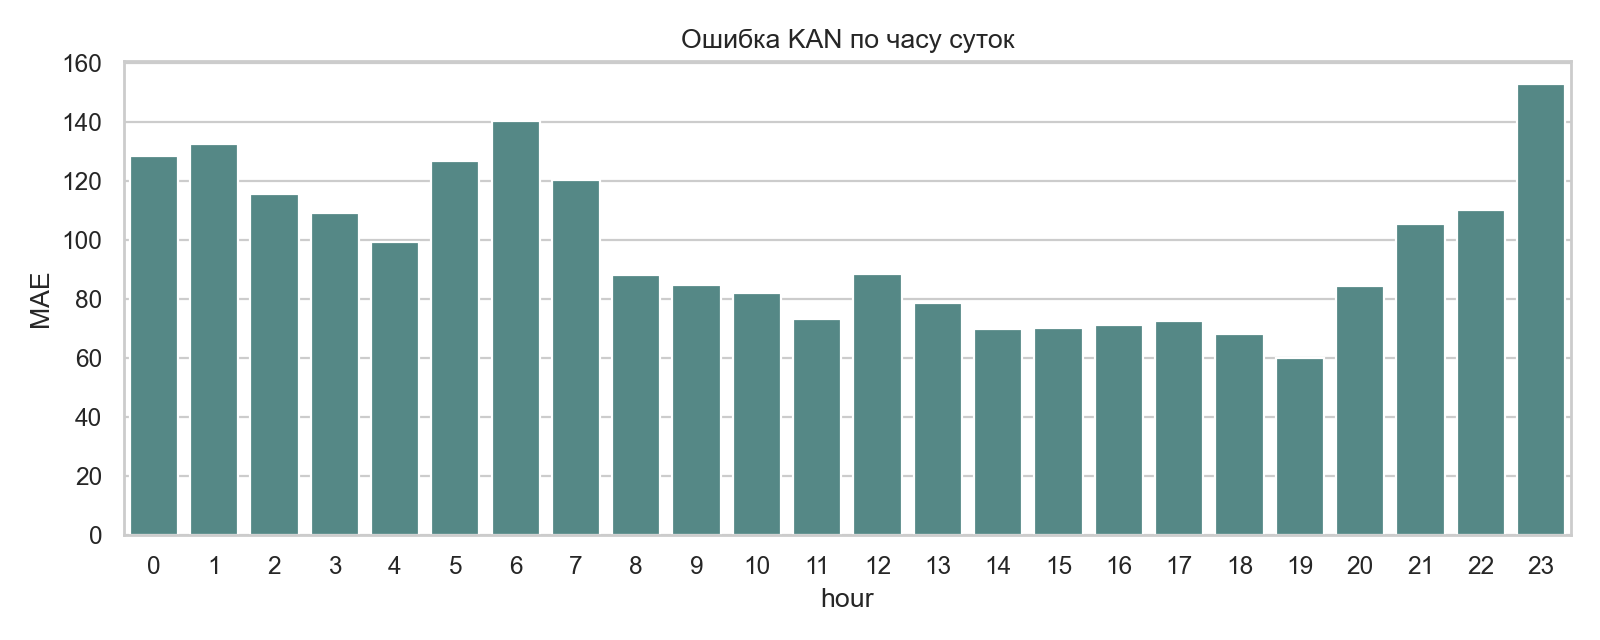

### russian_electricity_real_kan_top_region_rmse.png

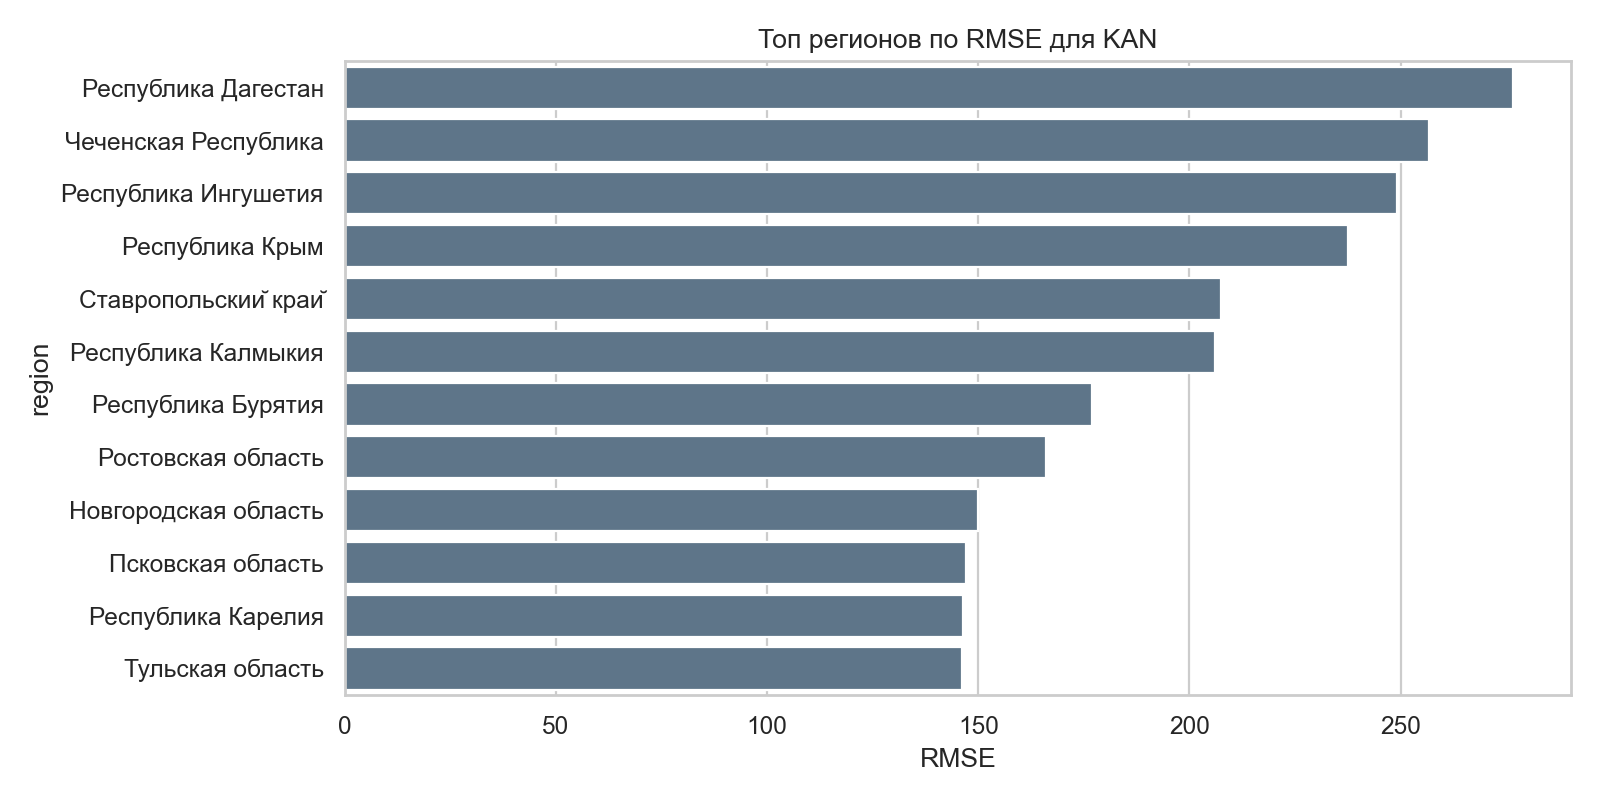

### russian_electricity_real_kan_actual_vs_pred.png

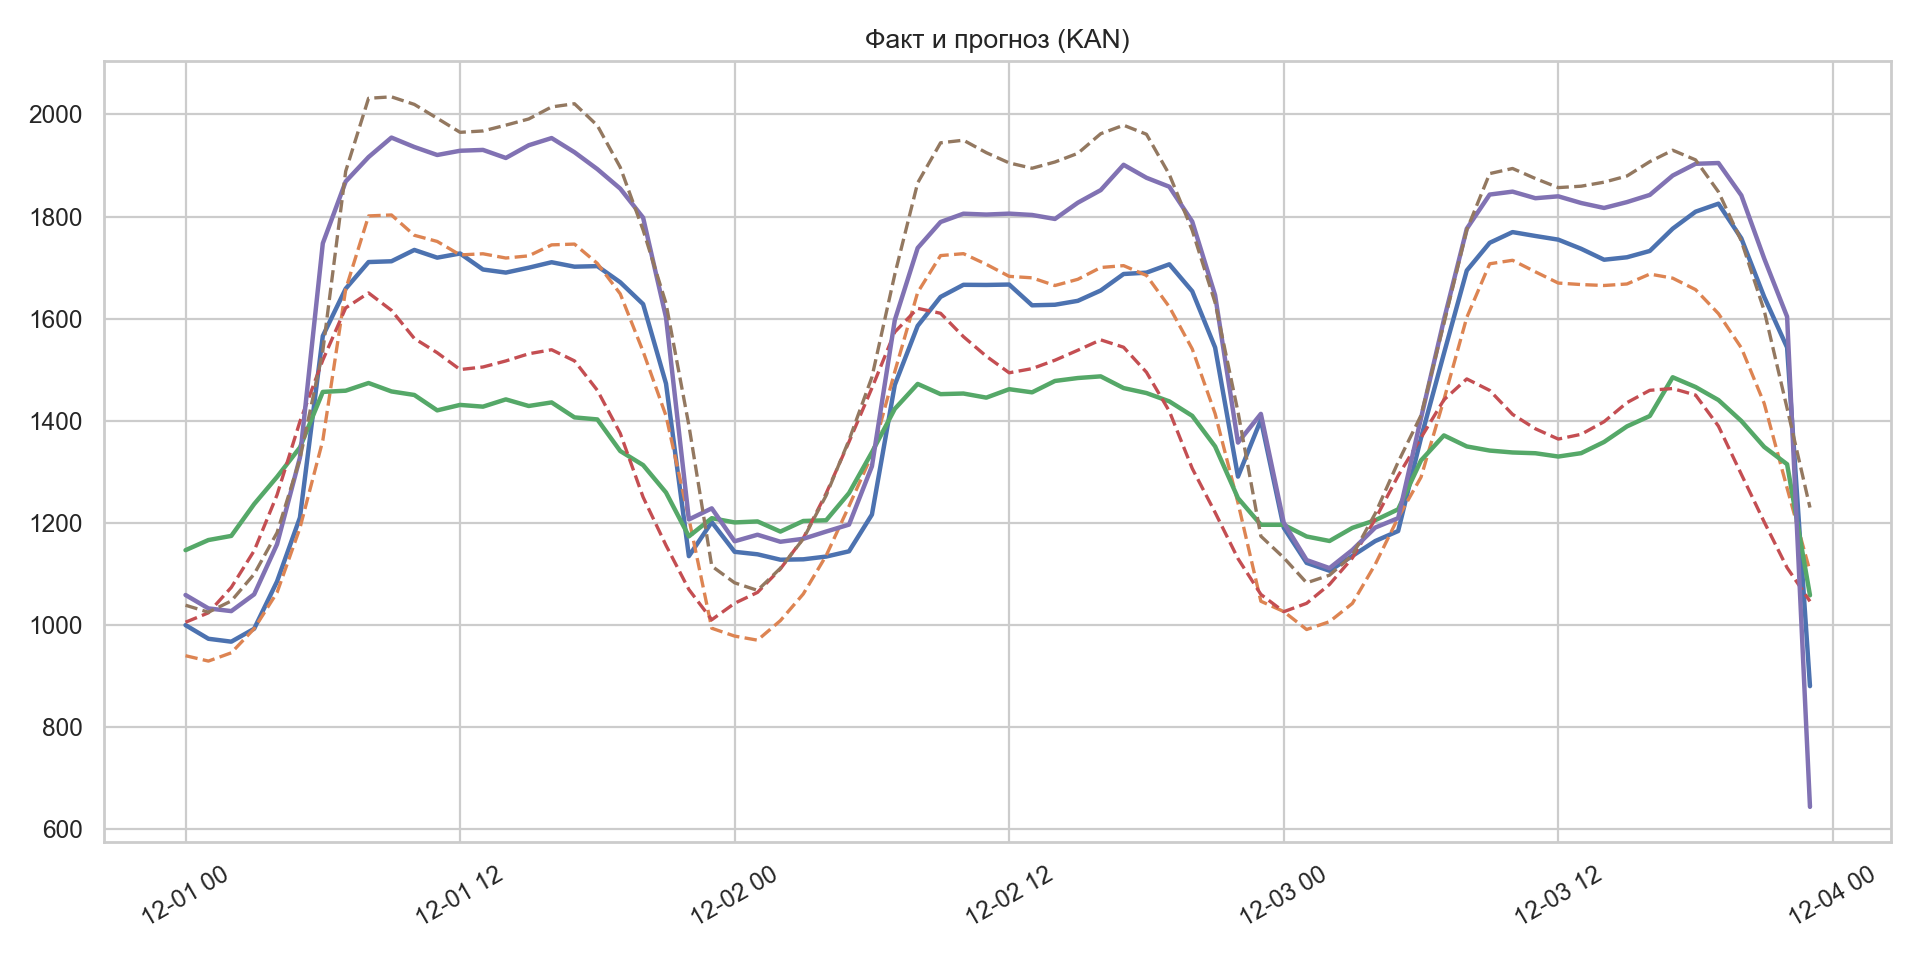

### russian_electricity_real_kan_residuals.png

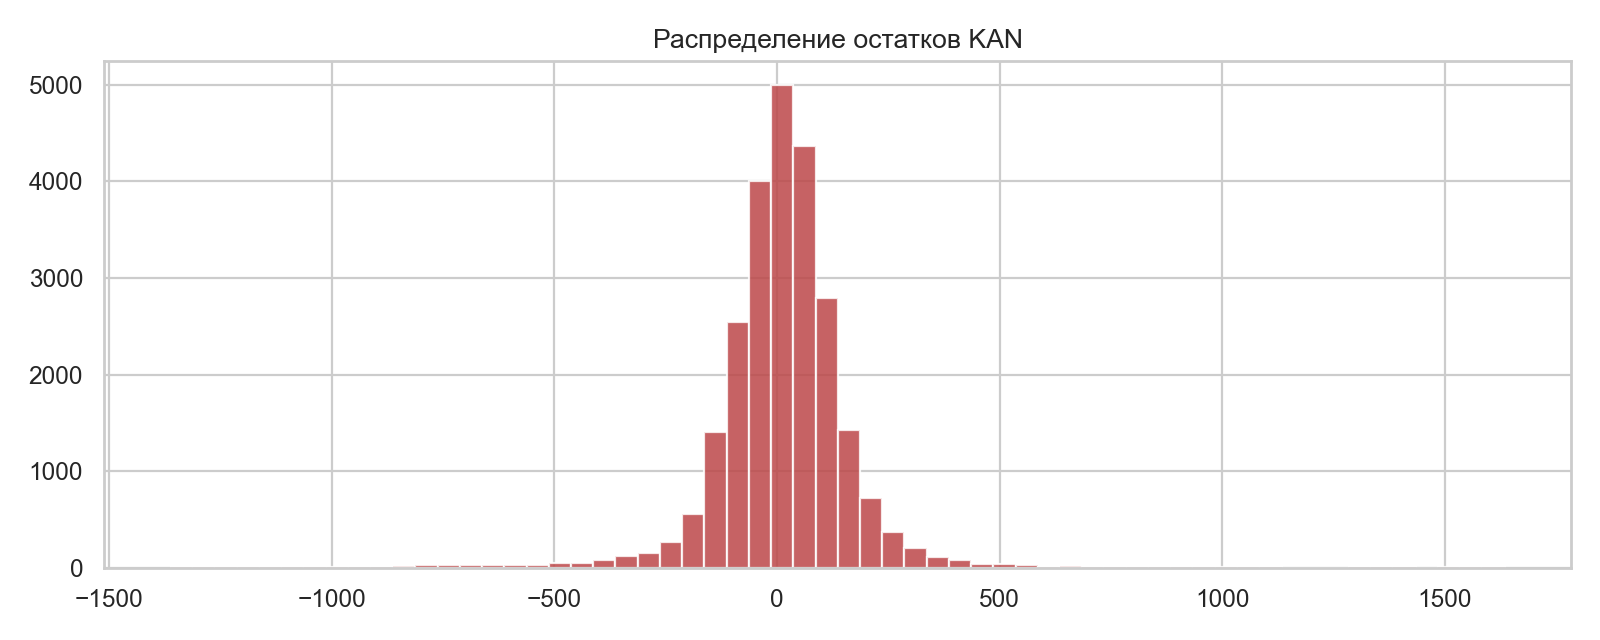

### russian_electricity_real_kan_training_curves.png

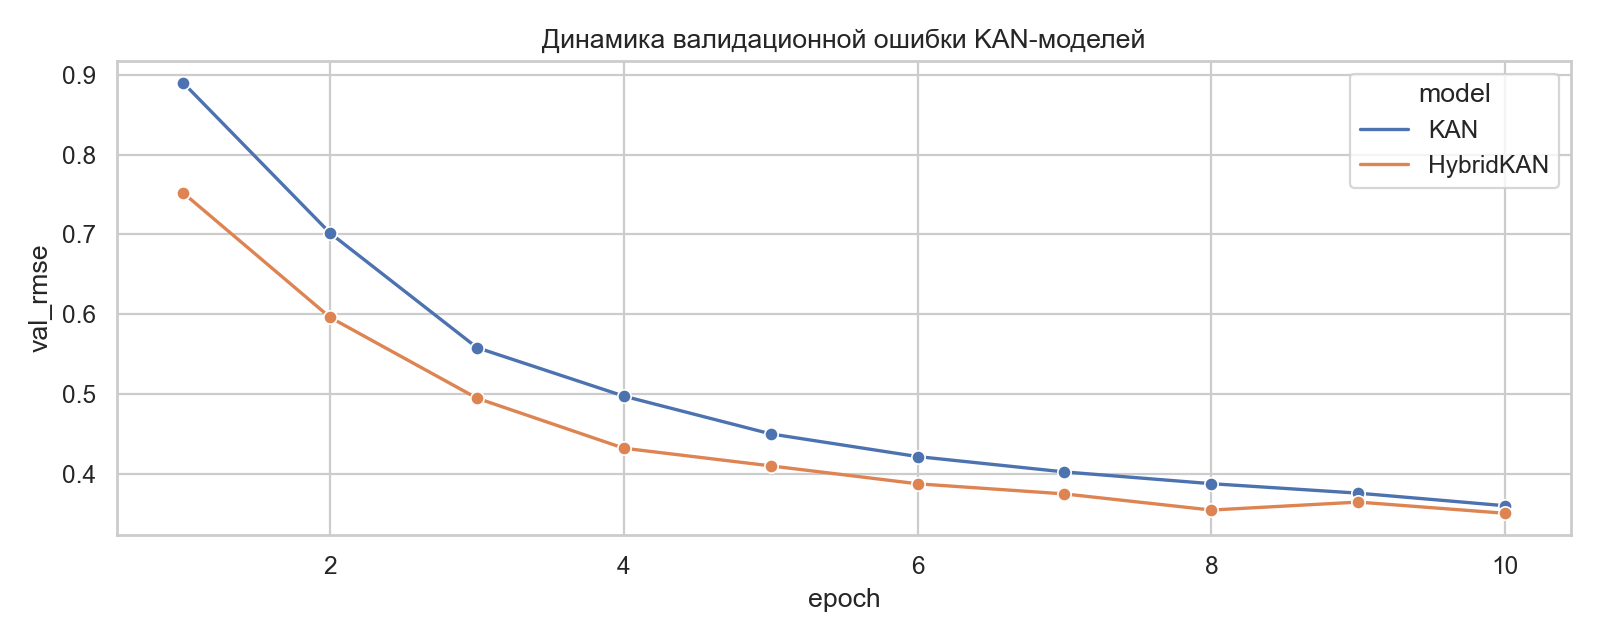

In [10]:
for img in [
    'russian_electricity_real_kan_mae_by_hour.png',
    'russian_electricity_real_kan_top_region_rmse.png',
    'russian_electricity_real_kan_actual_vs_pred.png',
    'russian_electricity_real_kan_residuals.png',
    'russian_electricity_real_kan_training_curves.png',
]:
    display(Markdown(f'### {img}'))
    display(Image(filename=str(OUT_DIR / img)))


## Интерпретация KAN

Ниже загружаются:
- `phi`-функции для `KAN` и `HybridKAN`;
- важность признаков первого `KAN`-слоя;
- важность каналов признаков для `HybridKAN`.


In [11]:
kan_importance = pd.read_csv(OUT_DIR / 'russian_electricity_kan_feature_importance.csv')
hybrid_importance = pd.read_csv(OUT_DIR / 'russian_electricity_hybridkan_feature_importance.csv')
channel_importance = pd.read_csv(OUT_DIR / 'russian_electricity_hybridkan_channel_importance.csv')

print('KAN feature importance')
display(kan_importance.head(15))
print('HybridKAN feature importance')
display(hybrid_importance.head(15))
print('HybridKAN channel importance')
display(channel_importance)


KAN feature importance


,feature,importance
0,purchase_price_rub_mwh,1.541034
1,prev_month_grid_loss_tariff_rate,1.373760
2,cos_hour,1.348325
3,sale_price_rub_mwh,1.339946
4,price_lag_1,1.080149
5,hour,1.055462
6,price_lag_24,1.017817
7,price_lag_168,0.979525
8,sin_hour,0.957202
9,Час,0.915235


HybridKAN feature importance


,feature,importance
0,purchase_price_rub_mwh,1.534535
1,sale_price_rub_mwh,1.232530
2,sin_hour,1.107933
3,cos_hour,1.062228
4,Час,0.894093
5,ВЭС.3_first,0.862220
6,hour,0.838029
7,АЭС.1_first,0.837661
8,price_lag_2,0.799499
9,price_lag_3,0.790747


HybridKAN channel importance


,group,baseline_rmse,rmse_after_permutation,rmse_delta
0,price_history,181.231644,518.464355,337.232712
1,calendar,181.231644,248.994415,67.762772
2,load_history,181.231644,209.344467,28.112823
3,generation_mix,181.231644,194.611008,13.379364
4,monthly_lagged,181.231644,188.945587,7.713943
5,flows_losses,181.231644,186.223511,4.991867
6,region,181.231644,183.961060,2.729416


### KAN phi-functions

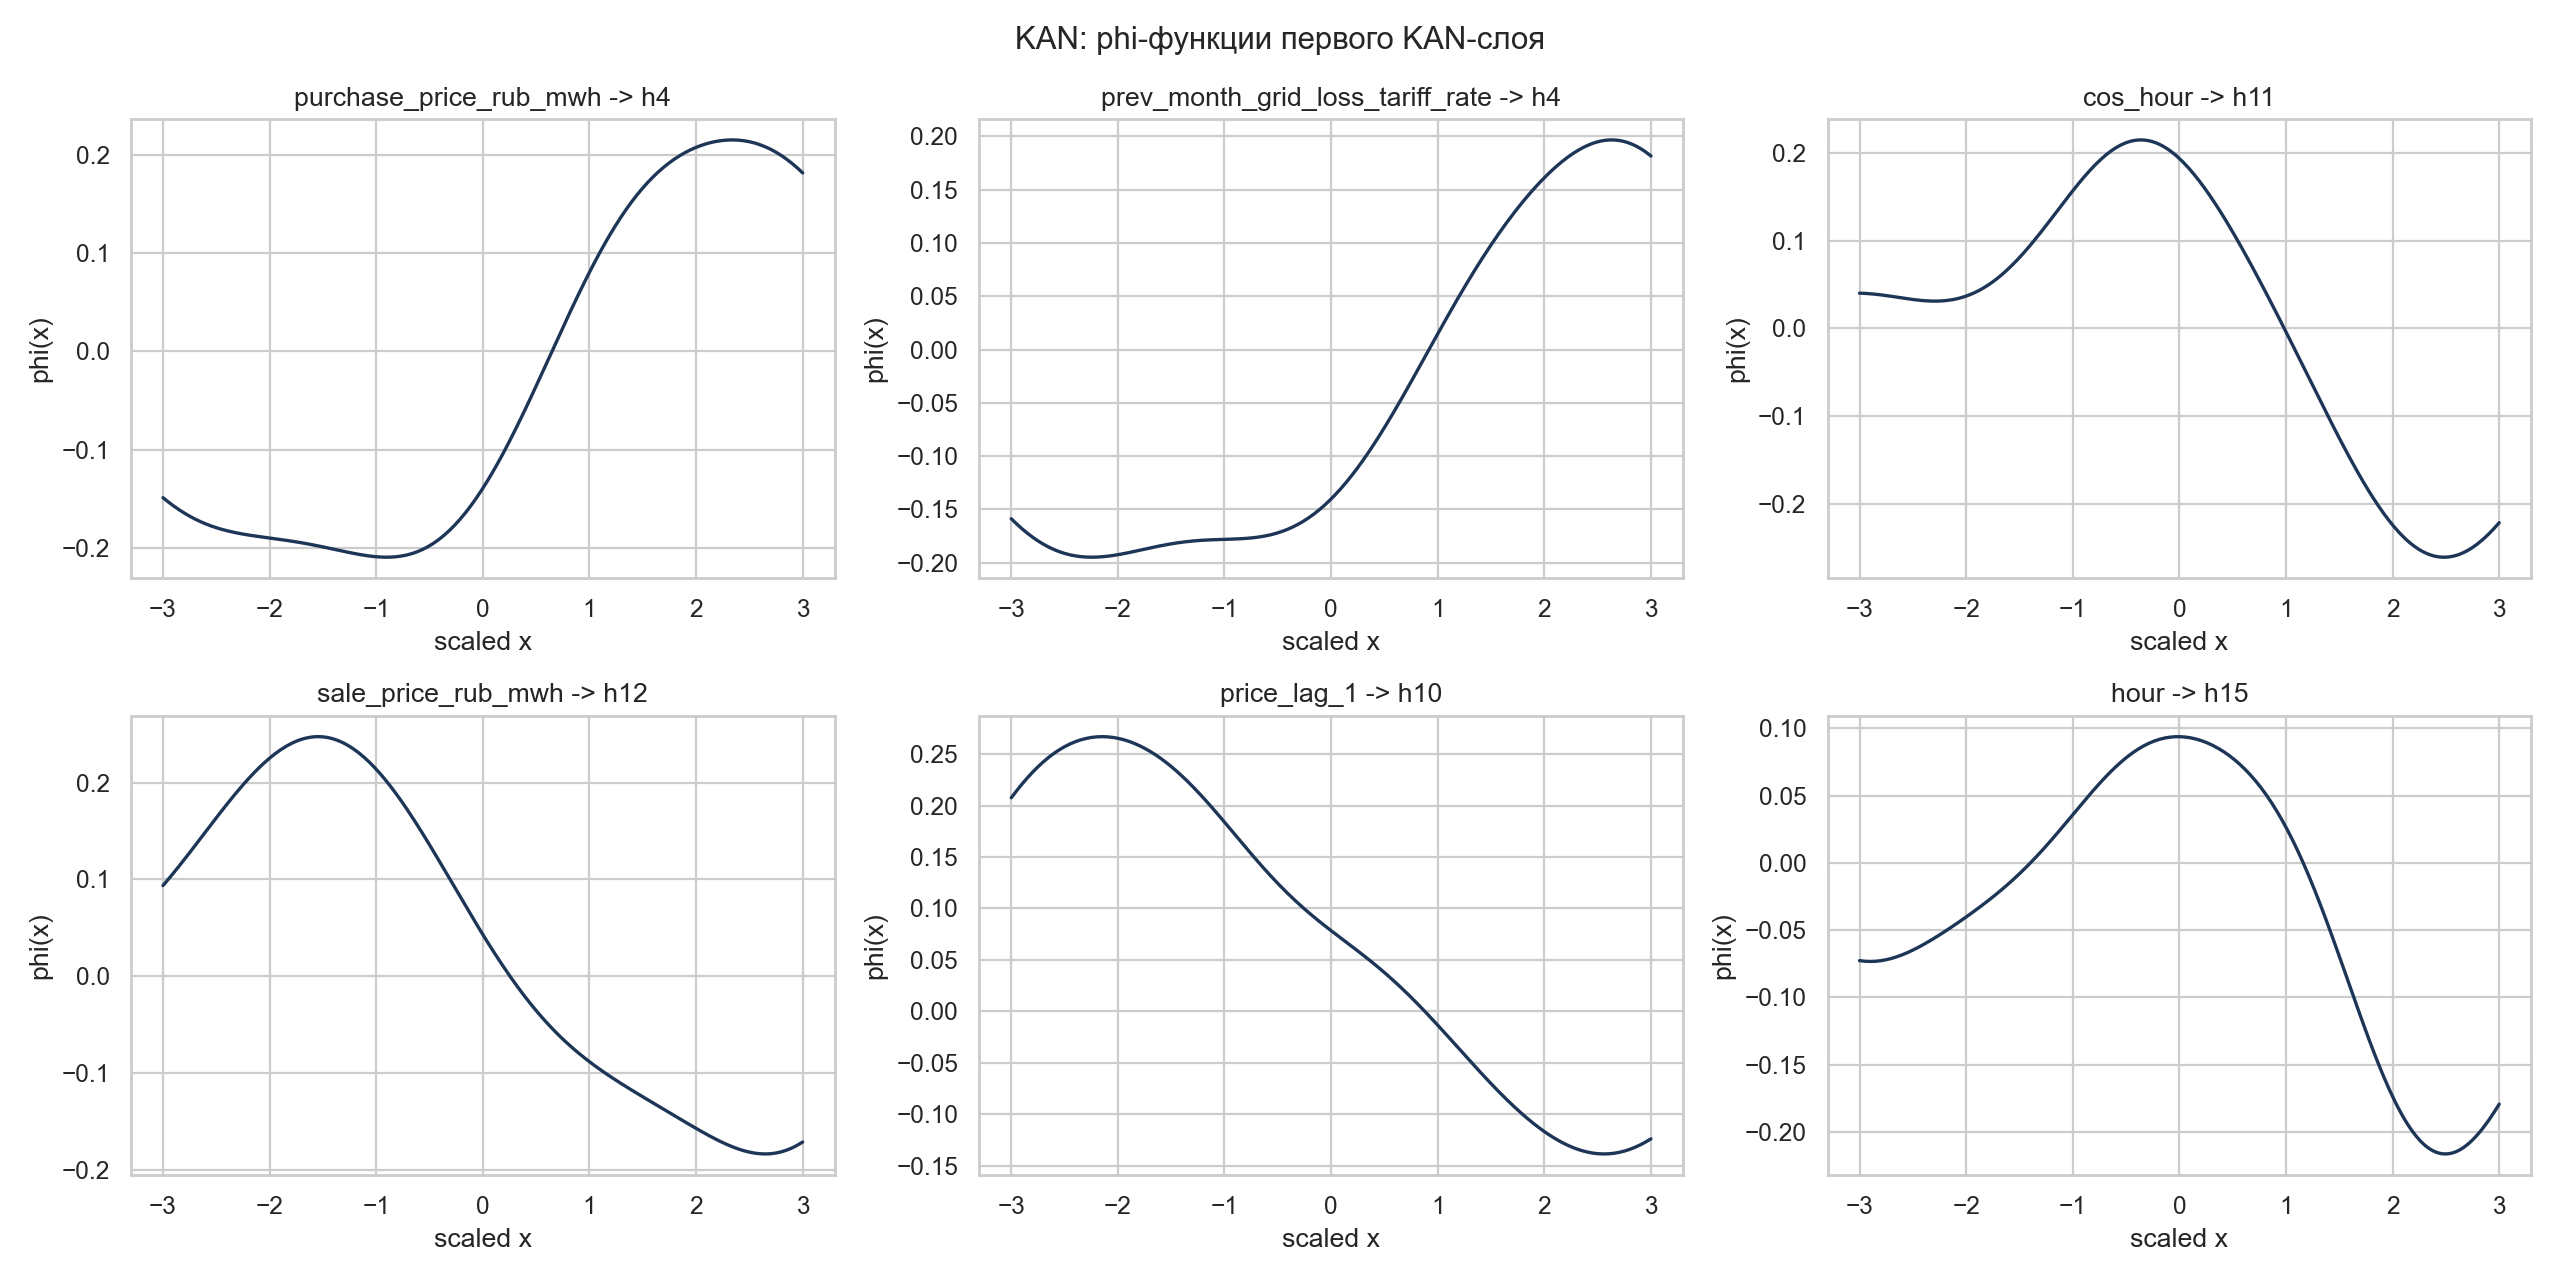

### HybridKAN phi-functions

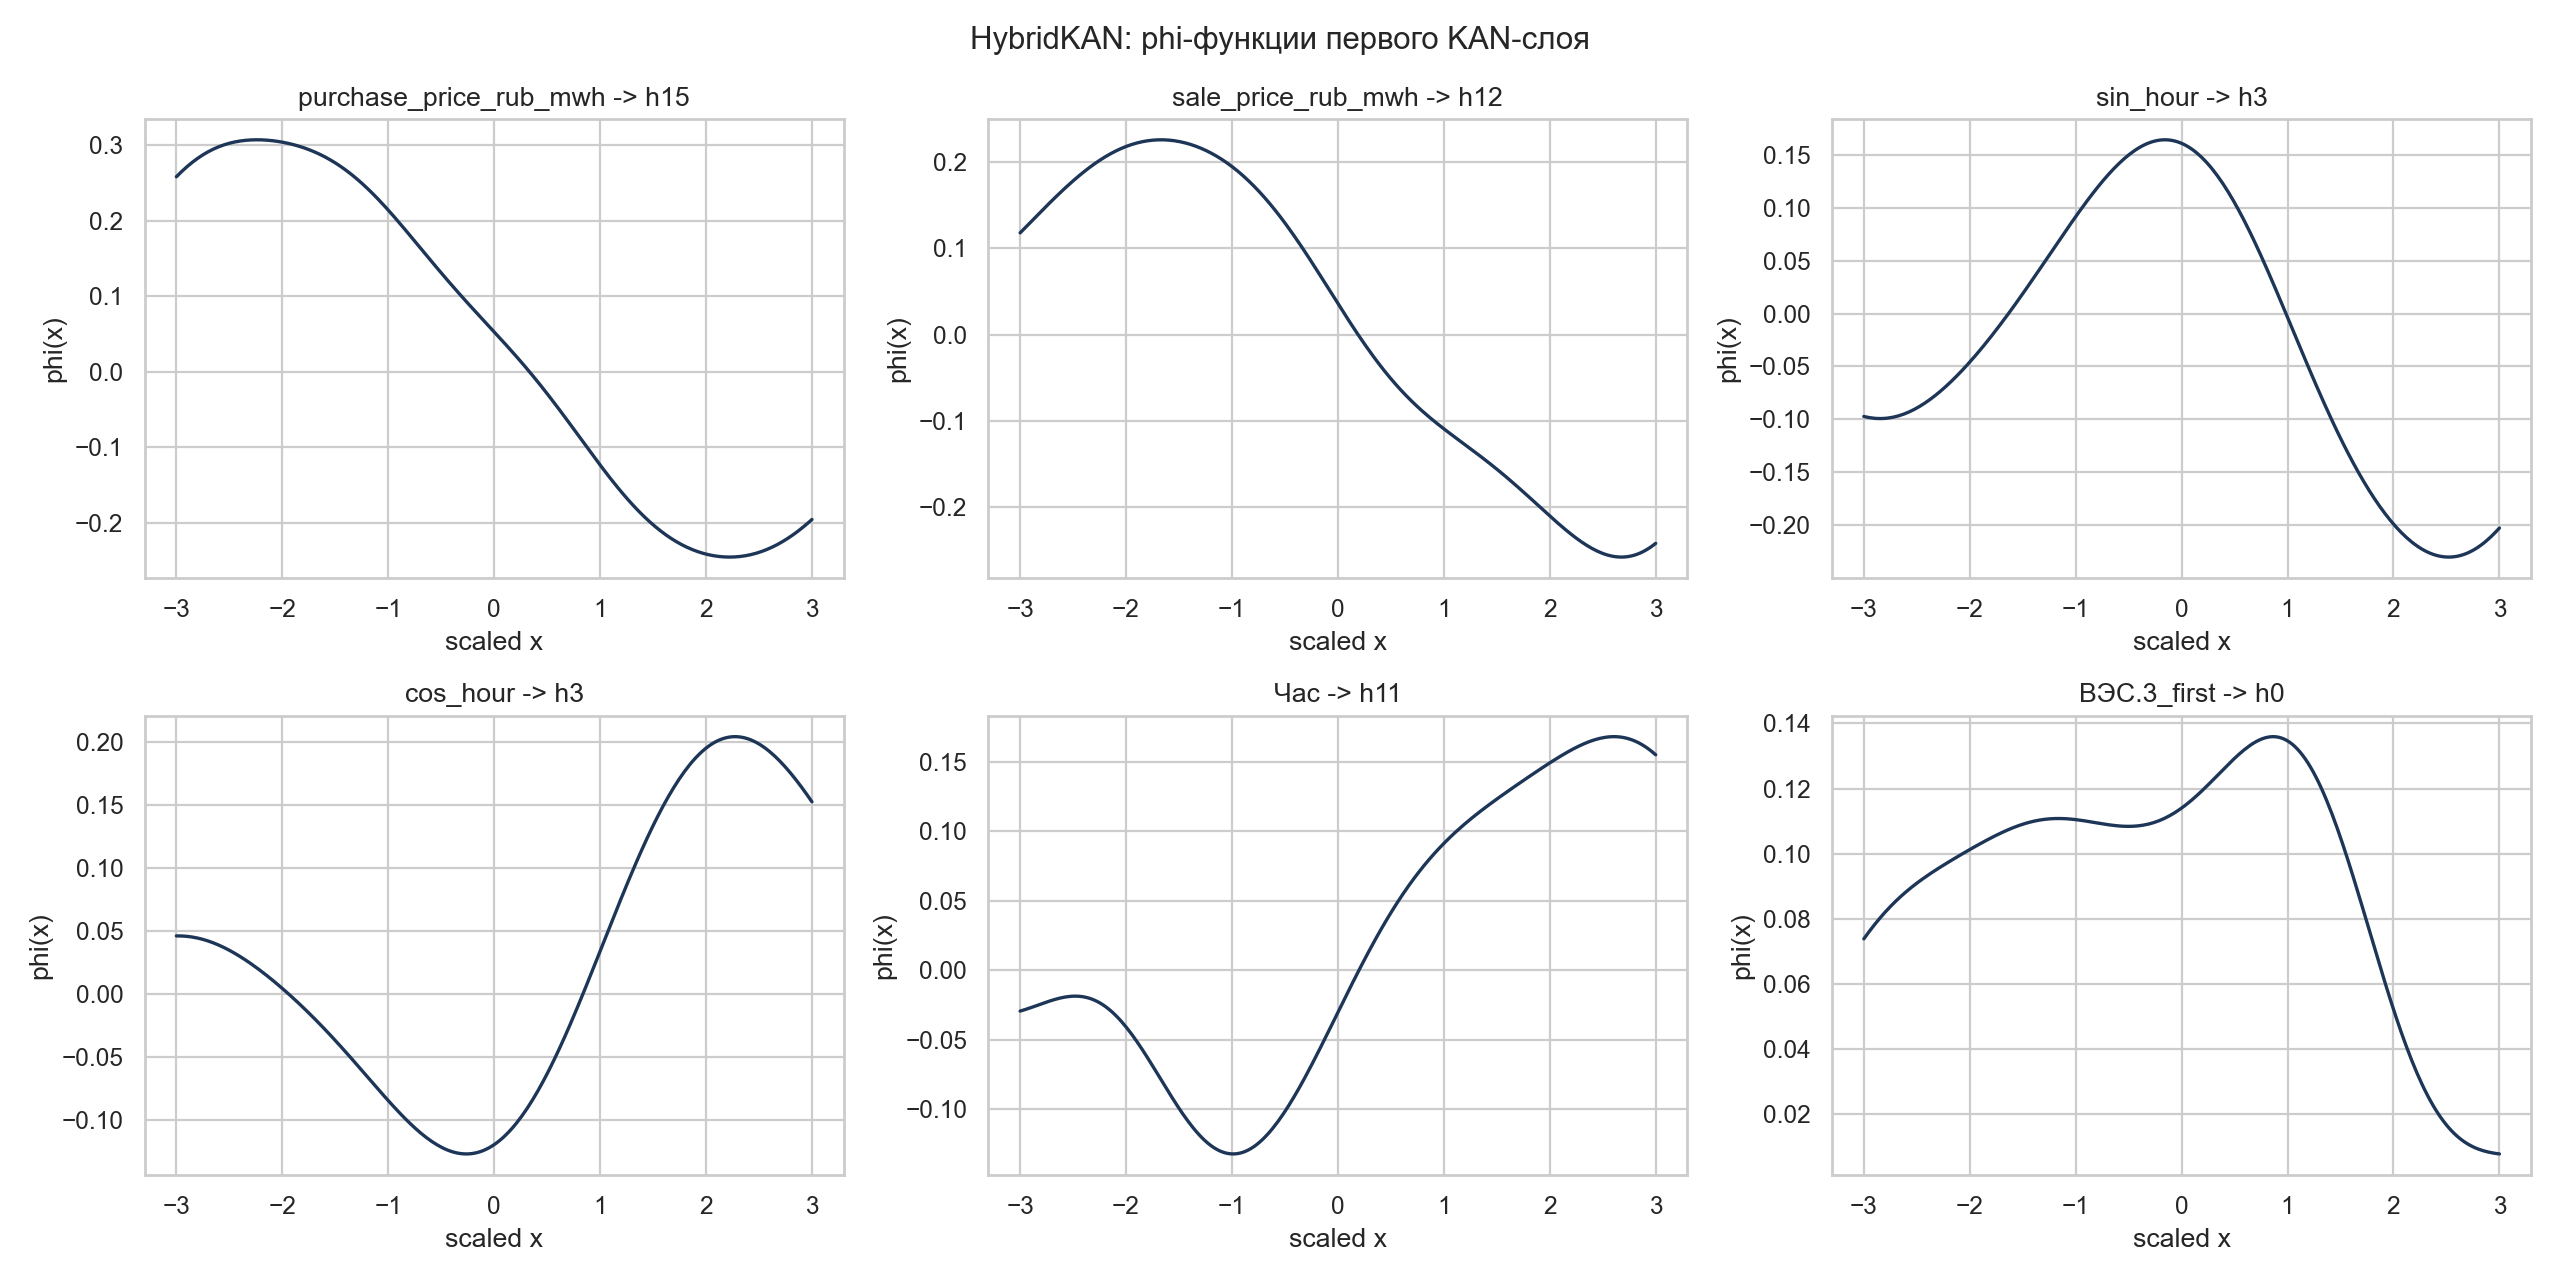

### Важность каналов признаков

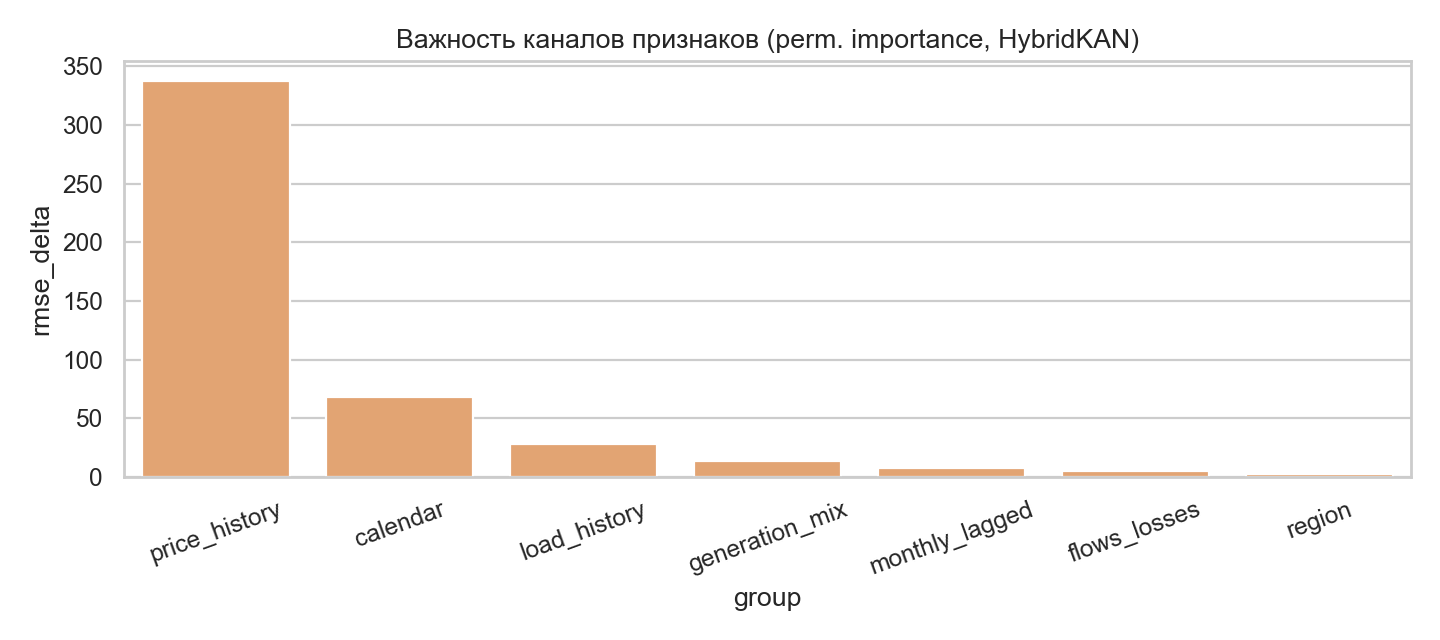

In [12]:
display(Markdown('### KAN phi-functions'))
display(Image(filename=str(OUT_DIR / 'kan_phi_functions.png')))

display(Markdown('### HybridKAN phi-functions'))
display(Image(filename=str(OUT_DIR / 'hybridkan_phi_functions.png')))

display(Markdown('### Важность каналов признаков'))
display(Image(filename=str(OUT_DIR / 'russian_electricity_hybridkan_channel_importance.png')))


## Предсказания и ошибки


In [13]:
pred_df = pd.read_csv(OUT_DIR / 'russian_electricity_real_kan_predictions.csv', parse_dates=['datetime'])
pred_df.head()


,datetime,region,hour,purchase_price_rub_mwh,target_price_t_plus_1,prediction,residual,abs_error,squared_error,model
0,2023-12-01 00:00:00,Новгородская область,0,1066.95,999.44,939.52610,59.913877,59.913877,3589.672652,KAN
1,2023-12-01 01:00:00,Новгородская область,1,999.44,972.72,928.99900,43.720977,43.720977,1911.523792,KAN
2,2023-12-01 02:00:00,Новгородская область,2,972.72,967.01,945.18710,21.822927,21.822927,476.240154,KAN
3,2023-12-01 03:00:00,Новгородская область,3,967.01,992.34,992.51965,-0.179653,0.179653,0.032275,KAN
4,2023-12-01 04:00:00,Новгородская область,4,992.34,1085.02,1063.33280,21.687236,21.687236,470.336220,KAN


In [14]:
err_hour = pd.read_csv(OUT_DIR / 'russian_electricity_real_kan_error_by_hour.csv')
err_region = pd.read_csv(OUT_DIR / 'russian_electricity_real_kan_error_by_region.csv')

display(err_hour)
display(err_region.head(15))


,hour,MAE,RMSE
0,0,128.698131,182.404878
1,1,132.490508,213.424653
2,2,115.689024,192.362897
3,3,109.078553,197.020195
4,4,99.207189,167.308111
5,5,126.932563,185.428497
6,6,140.445187,182.554301
7,7,120.548784,151.925564
8,8,88.270357,138.148760
9,9,84.842338,135.526374


,region,MAE,RMSE,mean_target
0,Республика Дагестан,186.110218,276.576031,2173.098102
1,Чеченская Республика,169.063098,256.672169,2085.764966
2,Республика Ингушетия,160.671864,249.244775,1960.328533
3,Республика Крым,174.170874,237.532695,1984.094199
4,Ставропольский край,128.803155,207.390259,1808.274509
5,Республика Калмыкия,135.583527,206.155791,1695.433957
6,Республика Бурятия,135.909445,176.970210,1398.755599
7,Ростовская область,108.365217,165.998626,1650.379462
8,Новгородская область,92.928154,150.021450,1469.177483
9,Псковская область,96.841342,147.102064,1503.045935


## Итоговые выводы

- корректная leakage-safe постановка делает эксперимент методически защищённым;
- на данных электроэнергии лучшие результаты дали tabular baseline-модели, в первую очередь `HistGradientBoosting`;
- лучшая модель семейства `KAN` в текущей конфигурации — чистый `KAN`;
- сильная сторона `KAN` в этом кейсе — интерпретируемость через `phi`-функции и каналы признаков, а не абсолютное лидерство по RMSE.
